In [1]:
import cv2
import numpy as np
from sklearn.cluster import KMeans
import webcolors


In [2]:
def rgb_to_hex(rgb_tuple):
    return '#%02x%02x%02x' % tuple(int(v) for v in rgb_tuple)

def closest_css3_name(requested_rgb):
    min_colors = {}
    css3_db = webcolors.CSS3_NAMES_TO_HEX
    for name, hex_value in css3_db.items():
        r_c, g_c, b_c = webcolors.hex_to_rgb(hex_value)
        rd = (r_c - requested_rgb[0])**2
        gd = (g_c - requested_rgb[1])**2
        bd = (b_c - requested_rgb[2])**2
        min_colors[(rd+gd+bd)] = name
    return min_colors[min(min_colors.keys())]

def dominant_color_kmeans(image_rgb, k=3):
    pixels = image_rgb.reshape(-1, 3)
    kmeans = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = kmeans.fit_predict(pixels)
    counts = np.bincount(labels)
    dominant = kmeans.cluster_centers_[np.argmax(counts)]
    return tuple(np.clip(dominant,0,255).astype(int))


In [3]:
image_path = r"C:\Users\lenovo\Pictures\Saved Pictures\premium_photo-1689539137236-b68e436248de.jpg"
img_bgr = cv2.imread(image_path)
if img_bgr is None:
    raise FileNotFoundError("❌ لم أستطع قراءة الصورة. تأكدي من المسار.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# تصغير الصورة إذا كانت كبيرة جدًا
h, w = img_rgb.shape[:2]
max_width = 800
if w > max_width:
    scale_factor = max_width / w
    img_rgb = cv2.resize(img_rgb, (int(w*scale_factor), int(h*scale_factor)))


In [4]:
clicked_points = []

def click_event(event, x, y, flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:  # عند النقر بالزر الأيسر
        clicked_points.append((x, y))
        print(f"📍 نقطة مختارة: ({x}, {y})")

cv2.namedWindow("اختر النقاط")
cv2.setMouseCallback("اختر النقاط", click_event)

while True:
    cv2.imshow("اختر النقاط", cv2.cvtColor(img_rgb, cv2.COLOR_RGB2BGR))
    key = cv2.waitKey(1) & 0xFF
    if key == 27:  # اضغط Esc للخروج
        break

cv2.destroyAllWindows()

if not clicked_points:
    raise ValueError("❌ لم يتم اختيار أي نقطة.")


📍 نقطة مختارة: (433, 164)
📍 نقطة مختارة: (436, 150)


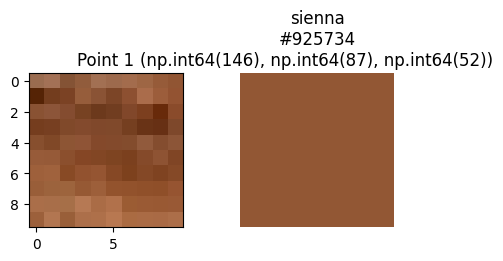

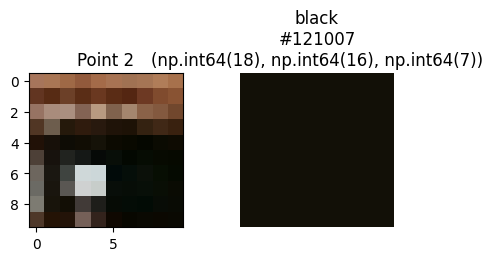

,Point,RGB,HEX,Color Name
0,"(433, 164)","(146, 87, 52)",#925734,sienna
1,"(436, 150)","(18, 16, 7)",#121007,black


In [5]:
roi_size = 5  # نصف حجم المربع حول النقطة
results = []

for i, (x, y) in enumerate(clicked_points):
    x_start = max(x - roi_size, 0)
    y_start = max(y - roi_size, 0)
    x_end = min(x + roi_size, img_rgb.shape[1]-1)
    y_end = min(y + roi_size, img_rgb.shape[0]-1)
    
    roi_rgb = img_rgb[y_start:y_end, x_start:x_end]
    dom_rgb = dominant_color_kmeans(roi_rgb, k=3)
    hex_code = rgb_to_hex(dom_rgb)
    color_name = closest_css3_name(dom_rgb)
    
    results.append({
        "Point": (x, y),
        "RGB": dom_rgb,
        "HEX": hex_code,
        "Color Name": color_name
    })
    
    # عرض المنطقة الصغيرة واللون السائد
    import matplotlib.pyplot as plt
    plt.figure(figsize=(5,2))
    plt.subplot(1,2,1)
    plt.imshow(roi_rgb)
    plt.title(f"Point {i+1}")
    
    swatch = np.zeros((100,100,3), dtype=np.uint8)
    swatch[:] = dom_rgb
    plt.subplot(1,2,2)
    plt.imshow(swatch)
    plt.title(f"{color_name}\n{hex_code}\n{dom_rgb}")
    plt.axis('off')
    plt.show()

import pandas as pd
df = pd.DataFrame(results)
df
